## Predictions with ensamble of models

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve
from evaluation_metrics import get_classification_report, get_f1_score, get_auc_score, get_eer_score
import random
from torch.utils.data import DataLoader
from transformers import ViTImageProcessor
from torchvision import transforms
from torch.utils.data import random_split
from MobileNet_model import get_trained_MobileNet_model
from ResNet50_model import get_trained_ResNet50_model
from VisionTransformer import get_trained_ViT_model

from import_data import get_sample_paths, PathLabelDataset, build_transform

/Users/majaambrozic/Documents/DRL/.venv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] `ViTImageProcessor` requires torchvision (not installed); falling back to `ViTImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `ViTImageProcessorPil` directly to silence this warning.


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Setup for models: generation of loaders

In [3]:
random.seed(42)
N_SAMPLES_PER_CLASS = 2

# Collect and filter all sample paths
paths, labels = get_sample_paths(n=N_SAMPLES_PER_CLASS)

# Get DataLoaders for training and testing: This function collects image paths and labels, creates a dataset, splits it into training and testing sets, and returns two separate DataLoaders.
def get_loaders(transform = None, batch_size=32, train_split=0.8): 
    # Create the full dataset
    if transform is None:
        full_dataset = PathLabelDataset(paths, labels, transform=build_transform(224))
    else:
        full_dataset = PathLabelDataset(paths, labels, transform=transform)

    # Calculate lengths for split
    train_len = int(len(full_dataset) * train_split)
    test_len = len(full_dataset) - train_len

    # Perform the random split
    train_ds, test_ds = random_split(
        full_dataset, 
        [train_len, test_len],
        generator=torch.Generator().manual_seed(42)
    )

    # Create two separate loaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, train_ds, test_ds

train_loader, test_loader, train_ds, test_ds = get_loaders()

Setup for Visual Transformer: generation of loaders, initialization of pretrained model and processor, transformation of every image to match ViT's expected input format

In [4]:
# Initialize model and processor
model_name = "google/vit-base-patch16-224-in21k" # pretrained model
processor = ViTImageProcessor.from_pretrained(model_name)

# Transformation of every image to match ViT's expected input format (resize, normalize, etc.)
vit_transform = transforms.Compose([
    transforms.Resize((processor.size["height"], processor.size["width"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

vit_train_loader, vit_test_loader, _, _ = get_loaders(vit_transform)

Set up two branch model

In [6]:
from TwoBranchResNet18 import TwoBranchResNet18, create_two_branch_dataloaders, fit_two_stage_model

two_branch_train_loader, two_branch_test_loader = create_two_branch_dataloaders(
    second_view_type="rotation_blur",
    blur_radius=2.0,
    rotation_degrees=15.0,
    batch_size=32,
)

two_branch_model = TwoBranchResNet18(num_classes=2, pretrained=False, dropout=0.3)
fit_two_stage_model(
    two_branch_model,
    two_branch_train_loader,
    two_branch_test_loader,
    phase1_epochs=3,
    phase2_epochs=5,
    phase1_lr=1e-3,
    phase2_lr=1e-4,
    device=device,
)

train_paths = [train_ds.dataset.paths[i] for i in train_ds.indices]
train_labels = [train_ds.dataset.labels[i] for i in train_ds.indices]
test_paths  = [test_ds.dataset.paths[i] for i in test_ds.indices]
test_labels  = [test_ds.dataset.labels[i] for i in test_ds.indices]

from TwoBranchVisionTransformer import TwoBranchVisionTransformer, TwoBranchVisionDataset
from TwoBranchVisionTransformer import fit_two_stage_model as fit_two_stage_vit_model

# Reuse the exact same train/test paths extracted above so all models predict on identical samples
two_branch_vit_train_ds = TwoBranchVisionDataset(
    train_paths, train_labels,
    second_view_type="rotation_blur",
    blur_radius=2.0,
    rotation_degrees=15.0,
)
two_branch_vit_test_ds = TwoBranchVisionDataset(
    test_paths, test_labels,
    second_view_type="rotation_blur",
    blur_radius=2.0,
    rotation_degrees=15.0,
)
two_branch_vit_train_loader = DataLoader(two_branch_vit_train_ds, batch_size=32, shuffle=True)
two_branch_vit_test_loader  = DataLoader(two_branch_vit_test_ds,  batch_size=32, shuffle=False)

two_branch_vit_model = TwoBranchVisionTransformer(num_classes=2, pretrained=True, dropout=0.3)
fit_two_stage_vit_model(
    two_branch_vit_model,
    two_branch_vit_train_loader,
    two_branch_vit_test_loader,
    phase1_epochs=3,
    phase2_epochs=5,
    phase1_lr=1e-4,
    phase2_lr=1e-5,
    device=device,
)


Phase 1:   0%|          | 0/3 [01:49<?, ?it/s]


KeyboardInterrupt: 

Prediction functions for each model: These functions take a model and a batch of images as input, perform a forward pass through the model, and return the predicted probabilities for the positive class (DR presence) in a format suitable for evaluation metrics.


In [ ]:
def cnn_predict_fn(model, images):
    logits = model(images)
    return torch.sigmoid(logits).squeeze()

def vit_predict_fn(model, images):
    logits = model(images) 
    return torch.softmax(logits, dim=1)[:, 1]

def two_branch_predict_fn(model, x_original, x_second_view):
    logits = model(x_original, x_second_view)
    return torch.softmax(logits, dim=1)[:, 1]

def two_branch_vit_predict_fn(model, x_original, x_second_view):
    logits = model(x_original, x_second_view)
    return torch.softmax(logits, dim=1)[:, 1]

Runs multiple models on a shared test set and fuses their predictions.

Supports soft voting (average of probabilities) and hard voting
(majority vote on binary predictions).  ``evaluate()`` returns rich metric
dicts so downstream cells can produce comparison plots without re-running
inference.

In [ ]:
class EnsembleVoter:
    def __init__(self, models: list[tuple[str, torch.nn.Module, callable, DataLoader]], device: str):
        self.models = models
        self.device = device

    # Run inference for one model, return (preds, probs, labels).
    # Handles both regular loaders (image, label) and two-branch loaders (x_orig, x_second, label).
    def _predict_single_model(self, model, predict_fn, loader):
        model.eval()
        all_preds = []
        all_probs = []
        all_labels = []

        with torch.no_grad():
            for batch in loader:
                if len(batch) == 2:
                    images, labels = batch
                    images = images.to(self.device)
                    probs = predict_fn(model, images).squeeze()
                elif len(batch) == 3:
                    x_original, x_second_view, labels = batch
                    x_original = x_original.to(self.device)
                    x_second_view = x_second_view.to(self.device)
                    probs = predict_fn(model, x_original, x_second_view).squeeze()
                else:
                    raise ValueError(f"Unsupported batch format: {len(batch)} items")

                preds = (probs > 0.5).float()

                if probs.dim() == 0:
                    all_probs.append(probs.item())
                    all_preds.append(preds.item())
                else:
                    all_probs.extend(probs.cpu().numpy())
                    all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        return np.array(all_preds), np.array(all_probs), np.array(all_labels)

    # Run ensemble prediction and return final predictions + per-model predictions
    def predict(self, mode="hard"):
        all_model_preds = {}
        all_model_probs = {}
        y_true = None

        for name, model, predict_fn, loader in self.models:
            preds, probs, labels = self._predict_single_model(model, predict_fn, loader)
            all_model_preds[name] = preds
            all_model_probs[name] = probs
            if y_true is None:
                y_true = labels
            print(f"  [{name}] predictions collected")

        if mode == "hard":
            stacked = np.stack(list(all_model_preds.values()), axis=0)
            final_preds = (stacked.mean(axis=0) >= 0.5).astype(float)
            final_probs = stacked.mean(axis=0)
        else:
            stacked_probs = np.stack(list(all_model_probs.values()), axis=0)
            final_probs = stacked_probs.mean(axis=0)
            final_preds = (final_probs >= 0.5).astype(float)

        return final_preds, final_probs, all_model_preds, all_model_probs, y_true
    
    # Run ensemble prediction, print metrics, and return data for plotting.
    def evaluate(self, mode="hard"):
        print(f"\nRunning ensemble ({mode} voting)...")
        final_preds, final_probs, all_model_preds, all_model_probs, y_true = self.predict(mode=mode)

        # Per-model metrics
        per_model_rows = []
        print("\n--- Individual Model Performance ---")
        for name, preds in all_model_preds.items():
            probs = all_model_probs[name]
            f1  = get_f1_score(y_true, preds)
            # auc = get_auc_score(y_true, probs)
            # eer = get_eer_score(y_true, probs)
            print(f"  {name}: F1 = {f1:.4f} ")
            # per_model_rows.append({"name": name, "f1": f1, "auc": auc, "eer": eer, "probs": probs})
            per_model_rows.append({"name": name, "f1": f1, "probs": probs})

        print("\n--- Ensemble Performance ---")
        ens_f1  = get_f1_score(y_true, final_preds)
        # ens_auc = get_auc_score(y_true, final_probs)
        # ens_eer = get_eer_score(y_true, final_probs)
        print(f"F1 Score:  {ens_f1:.4f}")
        # print(f"AUC Score: {ens_auc:.4f}")
        # print(f"EER Score: {ens_eer:.4f}")
        # print("\nClassification Report:\n", get_classification_report(y_true, final_preds))

        ensemble_row = {
            "name": f"ensemble_{mode}",
            "f1": ens_f1,
            # "auc": ens_auc,
            # "eer": ens_eer,
            "probs": final_probs,
        }
        return y_true, per_model_rows, ensemble_row

# Training and evaluation

In [ ]:
ensemble = EnsembleVoter(
    models=[
        ("ResNet50",             get_trained_ResNet50_model(train_loader, device),  cnn_predict_fn,            test_loader),
        ("MobileNetV2",          get_trained_MobileNet_model(train_loader, device), cnn_predict_fn,            test_loader),
        ("ViT",                  get_trained_ViT_model(vit_train_loader, device),   vit_predict_fn,            vit_test_loader),
        ("TwoBranchResNet18",    two_branch_model,                                  two_branch_predict_fn,     two_branch_test_loader),
        ("TwoBranchViT",         two_branch_vit_model,                              two_branch_vit_predict_fn, two_branch_vit_test_loader),
    ],
    device=device
)

Epoch 1, Loss: 0.5913
Epoch 2, Loss: 0.4856
Epoch 3, Loss: 0.4295
Epoch 4, Loss: 0.3895
Epoch 5, Loss: 0.3265
Unfreezing layer4
Unfreezing fc
Epoch 1, Loss: 0.2703
Epoch 2, Loss: 0.2080
Epoch 3, Loss: 0.1654
Epoch 1, Loss: 0.6467
Epoch 2, Loss: 0.5802
Epoch 3, Loss: 0.5506
Epoch 4, Loss: 0.5141
Epoch 5, Loss: 0.4962
Epoch 6, Loss: 0.4715
Epoch 7, Loss: 0.4662
Epoch 8, Loss: 0.4558
Epoch 9, Loss: 0.4204
Epoch 10, Loss: 0.4184
Epoch 1, Loss: 0.3561
Epoch 2, Loss: 0.3487
Epoch 3, Loss: 0.3293
Epoch 1/5 | train_loss: 0.6258
Epoch 2/5 | train_loss: 0.3837


In [ ]:
y_true, model_rows, hard_ensemble = ensemble.evaluate(mode="hard")
_,      _,          soft_ensemble = ensemble.evaluate(mode="soft")


Running ensemble (hard voting)...
  [ResNet50] predictions collected
  [MobileNetV2] predictions collected
  [ViT] predictions collected
  [TwoBranchViT] predictions collected

--- Individual Model Performance ---
  ResNet50: F1 = 0.0000 
  MobileNetV2: F1 = 0.0000 
  ViT: F1 = 0.0000 
  TwoBranchViT: F1 = 0.0000 

--- Ensemble Performance ---
F1 Score:  0.0000

Running ensemble (soft voting)...
  [ResNet50] predictions collected
  [MobileNetV2] predictions collected
  [ViT] predictions collected
  [TwoBranchViT] predictions collected

--- Individual Model Performance ---
  ResNet50: F1 = 0.0000 
  MobileNetV2: F1 = 0.0000 
  ViT: F1 = 0.0000 
  TwoBranchViT: F1 = 0.0000 

--- Ensemble Performance ---
F1 Score:  0.0000


# Plotting

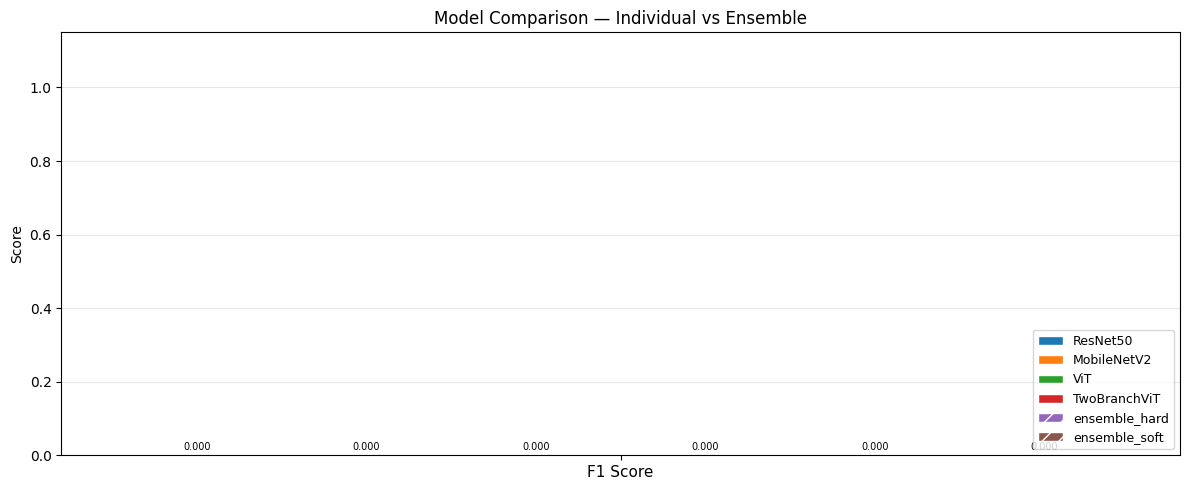

In [ ]:
def _palette(n):
    return [plt.cm.tab10(i) for i in range(n)]

# Grouped bar chart comparing every model and both ensemble variants per metric.
def plot_metric_bars(model_rows, hard_ensemble, soft_ensemble):
    """Args:
        model_rows: List of per-model metric dicts from ``EnsembleVoter.evaluate``.
        hard_ensemble: Ensemble metric dict for hard voting.
        soft_ensemble: Ensemble metric dict for soft voting.
    """
    all_rows = model_rows + [hard_ensemble, soft_ensemble]
    metrics  = [("f1", "F1 Score")]
    n        = len(all_rows)
    x        = np.arange(len(metrics))
    width    = 0.7 / n
    colors   = _palette(n)

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, row in enumerate(all_rows):
        offsets = x + (i - n / 2 + 0.5) * width
        vals    = [row[k] for k, _ in metrics]
        is_ens  = row["name"].startswith("ensemble")
        bars    = ax.bar(offsets, vals, width=width, color=colors[i],
                         hatch="//" if is_ens else "", edgecolor="white", label=row["name"])
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _, lbl in metrics], fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title("Model Comparison — Individual vs Ensemble")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("./results/multiple_models_metric_bars.png")
    plt.show()

# ROC curve for every model and both ensemble variants on one axis.
def plot_roc_curves(y_true, model_rows, hard_ensemble, soft_ensemble):
    """Args:
        y_true: Ground-truth binary labels, shape (N,).
        model_rows: List of per-model metric dicts (must contain ``"probs"``).
        hard_ensemble: Ensemble metric dict for hard voting.
        soft_ensemble: Ensemble metric dict for soft voting.
    """
    all_rows = model_rows + [hard_ensemble, soft_ensemble]
    colors   = _palette(len(all_rows))

    fig, ax = plt.subplots(figsize=(7, 6))
    for i, row in enumerate(all_rows):
        fpr, tpr, _ = roc_curve(y_true, row["probs"])
        is_ens = row["name"].startswith("ensemble")
        ax.plot(fpr, tpr, color=colors[i], lw=2,
                linestyle="--" if is_ens else "-",
                label=f"{row['name']} (AUC={row['auc']:.3f})")

    ax.plot([0, 1], [0, 1], "k:", lw=1, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves — All Models")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("./results/multiple_models_roc_curves.png")
    plt.show()

# Side-by-side confusion matrix heatmaps for the two ensemble variants.
def plot_confusion_matrices(y_true, hard_ensemble, soft_ensemble):
    """Args:
        y_true: Ground-truth binary labels, shape (N,).
        hard_ensemble: Ensemble metric dict for hard voting.
        soft_ensemble: Ensemble metric dict for soft voting.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    tick_labels = ["Real", "Fake"]

    for ax, row in zip(axes, [hard_ensemble, soft_ensemble]):
        cm     = confusion_matrix(y_true, (row["probs"] >= 0.5).astype(int))
        im     = ax.imshow(cm, cmap="Blues")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks([0, 1]); ax.set_xticklabels(tick_labels)
        ax.set_yticks([0, 1]); ax.set_yticklabels(tick_labels)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(row["name"])
        thresh = cm.max() / 2
        for r in range(2):
            for c in range(2):
                ax.text(c, r, str(cm[r, c]), ha="center", va="center",
                        color="white" if cm[r, c] > thresh else "black",
                        fontsize=14, fontweight="bold")

    fig.suptitle("Confusion Matrices — Ensemble Variants", fontsize=13)
    plt.tight_layout()
    plt.savefig("./results/multiple_models_confusion_matrices.png")
    plt.show()

# Run all visualisations
plot_metric_bars(model_rows, hard_ensemble, soft_ensemble)
# plot_roc_curves(y_true, model_rows, hard_ensemble, soft_ensemble)
# plot_confusion_matrices(y_true, hard_ensemble, soft_ensemble)